In [49]:
!pip install nbformat

In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [50]:
df=sns.load_dataset('titanic')

In [51]:
df.head(2)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False


In [52]:
x=df[['age','fare']]
y=df['survived']

In [53]:
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

# Fill missing 'age' values with the mean of the 'age' column in X_train
X_train['age'].fillna(X_train['age'].mean(), inplace=True)
X_test['age'].fillna(X_test['age'].mean(), inplace=True)

/tmp/ipython-input-149143300.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train['age'].fillna(X_train['age'].mean(), inplace=True)
/tmp/ipython-input-149143300.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

In [54]:
clf = DecisionTreeClassifier()
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
accuracy_score(y_test,y_pred)

0.6368715083798883

In [57]:
ka = KBinsDiscretizer(n_bins=20,encode='ordinal',strategy='quantile')
kf = KBinsDiscretizer(n_bins=20,encode='ordinal',strategy='quantile')

In [60]:
t = ColumnTransformer([
    ('a',ka,[0]),
    ('b',kf,[1])
])

In [75]:
t.fit(X_train)
xtt = t.transform(X_test)
xt=t.transform(X_train)
t.named_transformers_['a'].bin_edges_

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(


array([array([ 0.42      ,  4.        , 16.        , 18.        , 21.        ,
              22.        , 24.        , 26.        , 28.        , 29.49884615,
              30.        , 32.        , 35.        , 38.        , 42.        ,
              47.        , 54.        , 80.        ])                         ],
      dtype=object)

In [63]:
t.named_transformers_['b'].bin_edges_

array([array([  0.      ,   7.225   ,   7.55    ,   7.75    ,   7.88916 ,
                7.925   ,   8.05    ,   8.824995,  10.5     ,  13.      ,
               14.4542  ,  16.1     ,  21.045   ,  26.      ,  26.55    ,
               30.5     ,  39.6875  ,  56.4958  ,  77.2875  , 116.30125 ,
              512.3292  ])                                               ],
      dtype=object)

In [65]:
xt

array([[14., 14.],
       [ 5.,  9.],
       [11.,  5.],
       ...,
       [13.,  9.],
       [ 1., 19.],
       [ 4., 18.]])

In [67]:
output = pd.DataFrame({
    'age':X_train['age'],
    'age_trf':xt[:,0],
    'fare':X_train['fare'],
    'fare_trf':xt[:,1]
})

In [70]:
output['age_labels'] = pd.cut(x=X_train['age'],
                                    bins=t.named_transformers_['a'].bin_edges_[0].tolist())
output['fare_labels'] = pd.cut(x=X_train['fare'],
                                    bins=t.named_transformers_['b'].bin_edges_[0].tolist())

In [71]:
output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
788,1.000000,0.0,20.575,11.0,"(0.42, 4.0]","(16.1, 21.045]"
559,36.000000,12.0,17.400,11.0,"(35.0, 38.0]","(16.1, 21.045]"
252,62.000000,16.0,26.550,14.0,"(54.0, 80.0]","(26.0, 26.55]"
466,29.498846,9.0,0.000,0.0,"(28.0, 29.499]",NaN
348,3.000000,0.0,15.900,10.0,"(0.42, 4.0]","(14.454, 16.1]"


In [76]:
clf = DecisionTreeClassifier()
clf.fit(xt,y_train)
y_pred2 = clf.predict(xtt)
accuracy_score(y_test,y_pred2)

0.659217877094972

In [87]:
def discretize(bins,strategy):
    ka = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    kf = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)

    t = ColumnTransformer([
        ('a',ka,[0]), # Use ka defined in this function
        ('b',kf,[1])  # Use kf defined in this function
    ])

    # Create a cleaned copy of x and handle NaNs for transformation and cross_val_score
    x_cleaned = x.copy()
    x_cleaned['age'].fillna(x_cleaned['age'].mean(), inplace=True)
    # 'fare' generally has fewer NaNs but it's good practice to handle it if needed
    x_cleaned['fare'].fillna(x_cleaned['fare'].mean(), inplace=True)

    xt = t.fit_transform(x_cleaned) # Use the cleaned data for transformation
    # Apply cross_val_score to the cleaned 'x' and 'y' from titanic
    print(np.mean(cross_val_score(DecisionTreeClassifier(),x_cleaned,y,cv=10,scoring='accuracy')))

    plt.figure(figsize=(8,3))
    plt.subplot(121)
    plt.hist(x['age'],color='red') # Keep original x for 'Before' plot
    plt.title("Before Age")

    plt.subplot(122)
    plt.hist(xt[:,0])
    plt.title("After Age Discretization")

    plt.show()

    plt.figure(figsize=(8,3))
    plt.subplot(121)
    plt.hist(x['fare'],color='red') # Keep original x for 'Before' plot
    plt.title("Before Fare")

    plt.subplot(122)
    plt.hist(xt[:,1])
    plt.title("After Fare Discretization")

    plt.show()

/tmp/ipython-input-2500226227.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  x_cleaned['age'].fillna(x_cleaned['age'].mean(), inplace=True)
/tmp/ipython-input-2500226227.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

0.6532209737827716


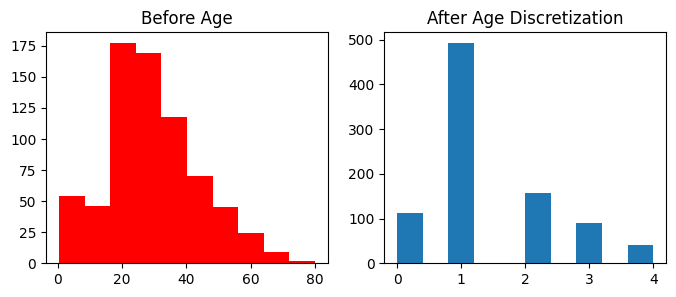

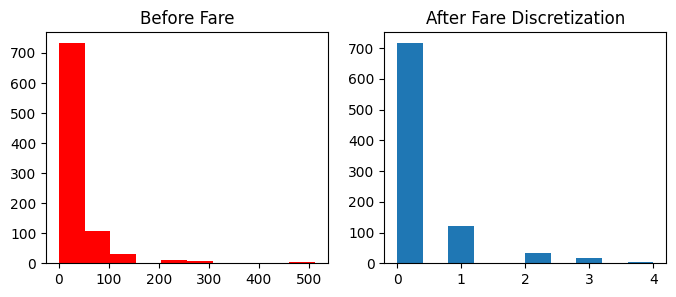

In [88]:
discretize(5,'kmeans')